In [51]:
!pip install datasets

Importing Libraries

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

Loading the dataset

In [53]:
dataset = load_dataset("dair-ai/emotion")

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(train_df.head())

                                                text  label
0                            i didnt feel humiliated      0
1  i can go from feeling so hopeless to so damned...      0
2   im grabbing a minute to post i feel greedy wrong      3
3  i am ever feeling nostalgic about the fireplac...      2
4                               i am feeling grouchy      3


Checking dataset

In [54]:
print(train_df.shape)
print(test_df.shape)

train_df['label'].value_counts()

(16000, 2)
(2000, 2)


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


Converting Labels to Emotional Name

In [55]:
emotion_names = {

    0: "anger",
    1: "fear",
    2: "joy",
    3: "love",
    4: "sadness",
    5: "surprise"

}

train_df["emotion"] = train_df["label"].map(emotion_names)
test_df["emotion"] = test_df["label"].map(emotion_names)

train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,anger
1,i can go from feeling so hopeless to so damned...,0,anger
2,im grabbing a minute to post i feel greedy wrong,3,love
3,i am ever feeling nostalgic about the fireplac...,2,joy
4,i am feeling grouchy,3,love


Label Encoding

In [56]:
encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["emotion"])
y_test = encoder.transform(test_df["emotion"])

In [63]:
from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train, num_classes=len(emotion_names))
y_test_one_hot = to_categorical(y_test, num_classes=len(emotion_names))

Tokenization

In [57]:
vocab_size = 10000

tokenizer = Tokenizer(num_words=vocab_size,
                      oov_token="<OOV>")

tokenizer.fit_on_texts(train_df["text"])

Converting tokens to sequences

In [58]:
X_train = tokenizer.texts_to_sequences(train_df["text"])
X_test = tokenizer.texts_to_sequences(test_df["text"])

Padding

In [59]:
max_length = 40

X_train = pad_sequences(X_train,
                        maxlen=max_length,
                        padding="post")

X_test = pad_sequences(X_test,
                       maxlen=max_length,
                       padding="post")

Building the model

In [73]:
model = Sequential()

model.add(
    Embedding(input_dim=vocab_size,
              output_dim=64,
              input_length=max_length)
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(32, activation="relu")
)

model.add(
    Dense(6, activation="softmax")
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compiling the model

In [74]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

Training the model

In [75]:
history = model.fit(
    X_train,
    y_train_one_hot, # Use one-hot encoded labels for training
    validation_split=0.4,
    epochs=40,
    batch_size=64
)

Epoch 1/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.3227 - loss: 1.6167 - val_accuracy: 0.3336 - val_loss: 1.5809
Epoch 2/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.3261 - loss: 1.5872 - val_accuracy: 0.3336 - val_loss: 1.5719
Epoch 3/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.3476 - loss: 1.4892 - val_accuracy: 0.4119 - val_loss: 1.2858
Epoch 4/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.4360 - loss: 1.1598 - val_accuracy: 0.4437 - val_loss: 1.1653
Epoch 5/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.5008 - loss: 1.0013 - val_accuracy: 0.5584 - val_loss: 1.0530
Epoch 6/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.6830 - loss: 0.7870 - val_accuracy: 0.6570 - val_loss: 0.9653
Epoch 7/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - accuracy: 0.7554 - loss: 0.5988 - val_accuracy: 0.7100 - val_loss: 0.7713
Epoch 8/40
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - accuracy: 0.7933 - loss: 0.4845 - val_accu

Accuracy Plot

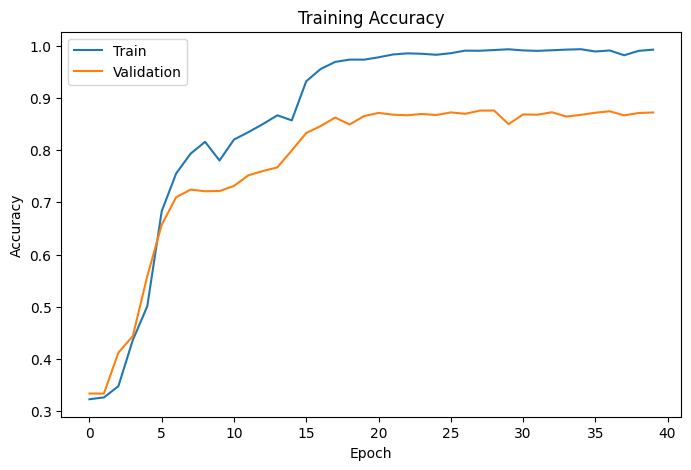

In [77]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")

plt.legend()
plt.show()

In [78]:
loss='categorical_crossentropy'

In [80]:
test_sentences = [
    "I am very happy",
    "I hate you",
    "I am scared",
    "I feel so sad",
    "I love my mother",
    "What a surprise!"
]

seq = tokenizer.texts_to_sequences(test_sentences)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

predictions = model.predict(seq)

for sentence, pred in zip(test_sentences, predictions):
    print(sentence, "->", encoder.inverse_transform([np.argmax(pred)])[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
I am very happy -> fear
I hate you -> love
I am scared -> sadness
I feel so sad -> anger
I love my mother -> joy
What a surprise! -> sadness


In [81]:
print(tokenizer.word_index.get("killing"))

2460


In [82]:
sentence = ["I feel like im killing someone"]

seq = tokenizer.texts_to_sequences(sentence)

print(seq)

[[2, 3, 14, 17, 2460, 148]]


Loss Plot

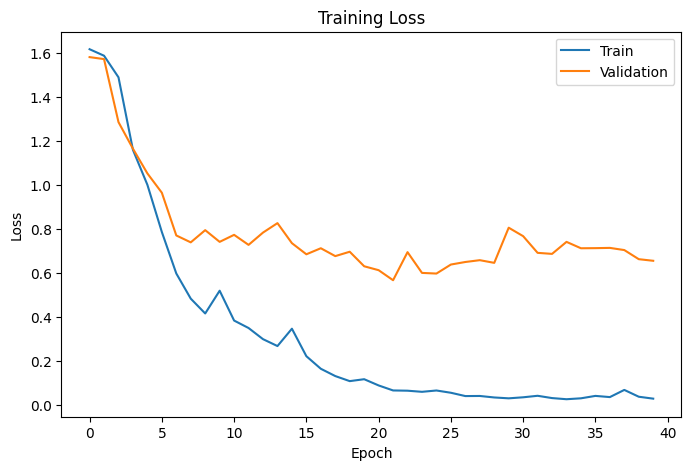

In [84]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")

plt.legend()
plt.show()

Evaluation Of Model

Classification Model

In [86]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_classes))

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       581
           1       0.87      0.94      0.91       695
           2       0.81      0.65      0.72       159
           3       0.88      0.84      0.86       275
           4       0.81      0.88      0.85       224
           5       0.74      0.65      0.69        66

    accuracy                           0.88      2000
   macro avg       0.84      0.81      0.82      2000
weighted avg       0.88      0.88      0.88      2000



Predicting your own sentence

In [87]:
sentence = ["I feel like im killing someone "]

seq = tokenizer.texts_to_sequences(sentence)
seq = pad_sequences(seq, maxlen=max_length, padding="post")

prediction = model.predict(seq)

emotion = encoder.inverse_transform([np.argmax(prediction)])

print("Predicted Emotion:", emotion[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Predicted Emotion: fear
